<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 3.1}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumna:} & Ledesma Cuevas Eduardo - 321249050 \\[6pt]
\textbf{Fecha de realización:} & 18/03/2026
\end{array}

</center>

# Fundamentos de Naive Bayes

**Objetivo**:
Implementar el algoritmo Naive Bayes para clasificar objetos basados en características continuas/discretas, comparando la lógica manual con la implementación de scikit-learn.

# Introducción Teórica
Naive Bayes se basa en la suposición de que las características (peso y textura) son independientes entre sí dada la clase. Aunque en la realidad esto rara vez se cumple, el algoritmo es extremadamente eficiente y sirve como "baseline" para modelos más complejos.

**Actividades de los alumnos**:

- **Cálculo manual**: Antes de programar, calculen en papel la probabilidad para una fruta de 180g y textura 6 usando los promedios de la tabla.

- **Análisis de la Gaussiana**: ¿Qué sucede si la desviación estándar de una característica es 0?  

- **Comparativa**: Modifique los datos para que una Toronja sea muy ligera. ¿Cómo reacciona el modelo? ¿Es más sensible al peso o a la textura?

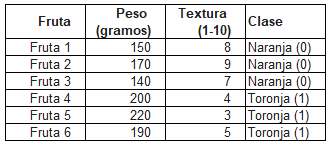

In [9]:
import numpy as np

#Datos:[Peso, Textura]

X = np.array ([
    [150,8],[170,9],[140,7],[130,8], #Clase 0: Naranja
    [200,4],[220,3],[190,5],[210,2] #Clase 1: Toronja
])

y = np.array([0,0,0,0,1,1,1,1])

# 1. Implementación con Bibliotecas (sklearn)

Esta versión muestra cómo el mismo problema se resuelve con estándares industriales.

In [10]:
from sklearn.naive_bayes import GaussianNB

# Crear y entrenar el modelo
clf = GaussianNB()
clf.fit(X,y)

# Predicción
nueva_fruta = [[180,6]]
prediccion = clf.predict(nueva_fruta)

print(f"Predicción Scikit-Learn: {'Naranja' if prediccion[0]==0 else 'Toronja'}")

Predicción Scikit-Learn: Toronja


# 1. Implementación "Desde Cero" (Numpy)

Usaremos un dataset pequeño donde clasificamos si una fruta es Naranja o Toronja basándonos en dos características: Peso (g) y Textura (1-10).El AlgoritmoLos alumnos deben calcular la probabilidad de que una fruta sea una Naranja ($N$) dado que pesa 150g ($P$) y tiene textura 8 ($T$):

$$P(N | P, T) \propto P(N) \cdot P(P | N) \cdot P(T | N)$$

In [40]:
def entrenar_naive_bayes(X,y):
  resumen = {}
  for clase in np.unique(y):
    datos_clase = X[y == clase]
    resumen[clase] = {
        'prior':len(datos_clase)/len(X),
        'promedios': datos_clase.mean(axis=0),
        'desviaciones': datos_clase.std(axis=0)
    }
  return resumen

In [41]:
import logging

# Configuración básica del logger
logging.basicConfig(level=logging.INFO, format = '%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)


def entrenar_naive_bayes(X,y):
  """
  Calcula la probabilidad a priori, la media y la
  desviación estándar para cada característica, agrupadas
  por las clases presentes en el vector de etiqueta.

  Arg:
  X(numpy.ndarray): Matriz de características de forma
  (n_samples, n_features)
  y(numpy.ndarray): Vector de etiquetas de forma (n_samples)

  Return:
  dict: Un diccionario donde cada llaves es una clase y el valor
  es otro diccionario con: prior, promedios y desviaciones


  """
  try:
    resumen = {}
    for clase in np.unique(y):
      datos_clase = X[y == clase]
      resumen[clase] = {
          'prior':len(datos_clase)/len(X),
          'promedios': datos_clase.mean(axis=0),
          'desviaciones': datos_clase.std(axis=0)
      }
    logger.info(f"Entrenamiento completado exitosamente.")
    return resumen

  except Exception as e:
    logger.error(f"Error durante el entrenamiento:{e}")
    raise

In [42]:
def pdf_gaussiana(X, promedio, desviacion):
  # Función de densidad de probabilidad para variables continuas
  exponente = np.exp(-((X-promedio)**2/(2*desviacion)))
  return (1/(np.sqrt(2 * np.pi) * desviacion)) * exponente

In [45]:
def predecir(resumen, instancia):
  probabilidades = {}
  for clase, stats in resumen.items():
    # Iniciamos con el log del Prior para evitar problemas de precisión
    log_prob = np.log(stats['prior'])
    for i in range(len(instancia)):
      p_x_dado_c = pdf_gaussiana(instancia[i],
                                 stats['promedios'][i],
                                 stats['desviaciones'][i])
      log_prob += np.log(p_x_dado_c)
    probabilidades[clase] = log_prob
  return max(probabilidades, key=probabilidades.get)

In [47]:
# Prueba manual
modelo = entrenar_naive_bayes(X,y)

nueva_fruta = [180,6] # ¿Es naranja o toronja?
resultado = predecir(modelo, nueva_fruta)

print(f"La fruta es: {'Naranja' if resultado == 0 else 'Toronja'}")

La fruta es: Toronja


<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>